In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pywt
from sklearn.preprocessing import StandardScaler


In [89]:
df = pd.read_csv("../data/NF-UNSW-NB15-v3.csv")

## Inspect data

In [90]:
df.shape

(2365424, 55)

In [91]:
df.head()

,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,...,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack
0,1424242193040,1424242193043,59.166.0.2,4894,149.171.126.3,53,17,5.0,146,2,...,0,0,0,0,0,0,0,0,0,Benign
1,1424242192744,1424242193079,59.166.0.4,52671,149.171.126.6,31992,6,11.0,4704,28,...,0,91,12,19,0,90,12,19,0,Benign
2,1424242190649,1424242193109,59.166.0.0,47290,149.171.126.9,6881,6,37.0,13662,238,...,0,1843,10,119,0,1843,5,88,0,Benign
3,1424242193145,1424242193146,59.166.0.8,43310,149.171.126.7,53,17,5.0,146,2,...,0,0,0,0,0,0,0,0,0,Benign
4,1424242193239,1424242193241,59.166.0.1,45870,149.171.126.1,53,17,5.0,130,2,...,0,0,0,0,0,0,0,0,0,Benign


In [92]:
df.columns

Index(['FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS', 'IPV4_SRC_ADDR',
       'L4_SRC_PORT', 'IPV4_DST_ADDR', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO',
       'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS',
       'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS',
       'DURATION_IN', 'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT',
       'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN',
       'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES',
       'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS',
       'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS',
       'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT',
       'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES',
       'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES',
       'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT',
       'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID', 'DNS_QUERY_TYPE',
       'DNS_TTL_ANSWER', 'FTP_COMMAN

In [94]:
df["Attack"].value_counts()

Attack
Benign            2237731
Exploits            42748
Fuzzers             33816
Generic             19651
Reconnaissance      17074
DoS                  5980
Backdoor             4659
Shellcode            2381
Analysis             1226
Worms                 158
Name: count, dtype: int64

## Categorise the useful data

Features such as IP address, ports, DNS IDs are not useful for CWT so we drop them

In [95]:
remove = [
    "FLOW_START_MILLISECONDS",
    "FLOW_END_MILLISECONDS",
    "IPV4_SRC_ADDR",
    "IPV4_DST_ADDR",
    "L4_SRC_PORT",
    "L4_DST_PORT",
    "PROTOCOL",
    "L7_PROTO",
    "DNS_QUERY_ID",
    "DNS_QUERY_TYPE",
    "ICMP_TYPE",
    "ICMP_IPV4_TYPE",
    "FTP_COMMAND_RET_CODE",
    "Label"
]

In [96]:
packet_size = [
    "NUM_PKTS_UP_TO_128_BYTES",
    "NUM_PKTS_128_TO_256_BYTES",
    "NUM_PKTS_256_TO_512_BYTES",
    "NUM_PKTS_512_TO_1024_BYTES",
    "NUM_PKTS_1024_TO_1514_BYTES"
]

In [97]:
src_to_dst_timing = [
    "SRC_TO_DST_IAT_MIN",
    "SRC_TO_DST_IAT_AVG",
    "SRC_TO_DST_IAT_MAX",
    "SRC_TO_DST_IAT_STDDEV"
]

In [98]:
dst_to_src_timing = [
    "DST_TO_SRC_IAT_MIN",
    "DST_TO_SRC_IAT_AVG",
    "DST_TO_SRC_IAT_MAX",
    "DST_TO_SRC_IAT_STDDEV"
]

In [99]:
byte_signal = [
    "IN_BYTES",
    "OUT_BYTES"
]

In [100]:
throughput_signal = [
    "SRC_TO_DST_AVG_THROUGHPUT",
    "DST_TO_SRC_AVG_THROUGHPUT"
]

## Remove NaN's or Inf values

In [104]:
cwt_columns = packet_size + src_to_dst_timing + dst_to_src_timing + byte_signal + throughput_signal

df_clean = df[cwt_columns].replace([np.inf, -np.inf], np.nan).dropna()

## Get a representative sample of each attack type

In [107]:
numeric_cols = cwt_columns.copy()

numeric_cols.append('Attack')

total_benign = 30000
df_benign = df_clean[df_clean['Attack'] == 'Benign'].sample(
    n=min(len(df_clean[df_clean['Attack'] == 'Benign']), total_benign),
    random_state=42
)

df_clean['Attack'] = df_clean['Attack'].astype(str)

max_attack_samples = 5000
attack_types = df_clean['Attack'].unique().tolist()
attack_types.remove('Benign')

attack_samples = []
for attack in attack_types:
    subset = df_clean[df_clean['Attack'] == attack]
    n_sample = min(len(subset), max_attack_samples)
    attack_samples.append(subset.sample(n=n_sample, random_state=42))

df_attack = pd.concat(attack_samples).reset_index(drop=True)

df_all = pd.concat([df_benign, df_attack]).reset_index(drop=True)

print(df_all['Attack'].value_counts())

Attack
Benign            30000
Fuzzers            5000
Exploits           5000
Reconnaissance     5000
Generic            5000
DoS                5000
Backdoor           4659
Shellcode          2381
Analysis           1226
Worms               158
Name: count, dtype: int64


## Extract 2000 attack types in each signal category 

In [108]:
attack_signals = {}

In [109]:
for attack_type in df_all['Attack'].unique():
    subset = df_all[df_all['Attack'] == attack_type]
    
    attack_signals[attack_type] = {
        'packet_size': subset[packet_size].values,
        'src_to_dst_timing': subset[src_to_dst_timing].values,
        'dst_to_src_timing': subset[dst_to_src_timing].values,
        'byte_signal': subset[byte_signal].values,
        'throughput_signal': subset[throughput_signal].values
    }

## Inspect

In [110]:
print("Packet size signals for DoS:")
print(pd.DataFrame(attack_signals['DoS']['packet_size']).head())

Packet size signals for DoS:
    0  1  2  3  4
0  14  2  0  2  0
1   0  0  0  2  0
2   2  0  0  0  0
3  14  0  0  2  0
4  16  2  2  0  0


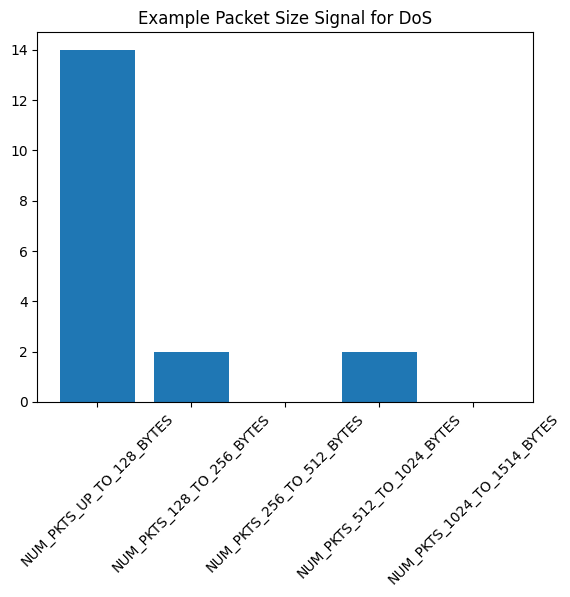

In [111]:
row_signal = attack_signals['DoS']['packet_size'][0]
plt.bar(range(len(row_signal)), row_signal)
plt.xticks(range(len(row_signal)), packet_size, rotation=45)
plt.title("Example Packet Size Signal for DoS")
plt.show()

## Calculate the CWT, extract the mean magnitude and the mean phase

CWT outputs a very large vector that cannot be used for model training. Instead, insightful data such as the mean magnitude and the mean phase is calculated from the CWT results to provide the model numeric outputs.

In [112]:
wavelet = 'cmor3.5-1'
scales = np.arange(1, 5)

In [113]:
signal_categories = {
    'pkt': packet_size,
    'src': src_to_dst_timing,
    'dst': dst_to_src_timing,
    'byte': byte_signal,
    'thr': throughput_signal
}

In [114]:
def cwt_mean_features(signal):
    coeffs, _ = pywt.cwt(signal, scales=scales, wavelet=wavelet)
    magnitude = np.abs(coeffs)
    phase = np.angle(coeffs)
    return magnitude.mean(), phase.mean()

In [115]:
def calculate_cwt_category(df, columns):
    signals = df[columns].values
    
    results = np.array([cwt_mean_features(row) for row in signals])
    mean_mag = results[:,0]
    mean_phase = results[:,1]
    
    return mean_mag, mean_phase

In [117]:
for cat, cols in signal_categories.items():
    mean_mag, mean_phase = calculate_cwt_category(df_all, cols)
    df_all[f'{cat}_mean'] = mean_mag
    df_all[f'{cat}_phase'] = mean_phase

In [118]:
df_all.shape

(63424, 28)

In [119]:
df_all.head()

,NUM_PKTS_UP_TO_128_BYTES,NUM_PKTS_128_TO_256_BYTES,NUM_PKTS_256_TO_512_BYTES,NUM_PKTS_512_TO_1024_BYTES,NUM_PKTS_1024_TO_1514_BYTES,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,...,pkt_mean,pkt_phase,src_mean,src_phase,dst_mean,dst_phase,byte_mean,byte_phase,thr_mean,thr_phase
0,4,0,0,0,0,0,0,0,0,0,...,0.370405,0.233364,0.000000,3.141593,0.000000,3.141593,15.100750,-0.956510,60402.998858,-0.956510
1,87,0,0,0,0,0,14,196,33,0,...,8.056298,0.233364,17.581824,0.051762,25.194885,0.049700,238.311096,-1.028469,3258.921129,-1.028469
2,4,0,0,0,0,0,0,0,0,0,...,0.370405,0.233364,0.000000,3.141593,0.000000,3.141593,13.727221,-0.979326,54908.885109,-0.979326
3,20,0,6,0,6,0,88,999,264,0,...,1.942756,-0.027926,85.793764,0.017670,87.906681,0.021966,974.560326,-1.251845,6767.786108,-1.251847
4,6,2,0,0,0,0,6,19,8,0,...,0.491744,0.075951,1.311885,0.052357,1.591377,0.038745,48.699588,-0.204543,10529.588968,-0.204542


## Add label ready for supervised training

In [121]:
df_all['Label'] = (df_all['Attack'] != 'Benign').astype(int)
df_all.to_csv('cwt_supervised.csv', index=False)